<a href="https://colab.research.google.com/github/smithve-laf/smith-repository-notebook/blob/main/neur_coding_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Victoria Smith**

*Neural Data Analysis*

04/30/2026

In [17]:
#importing modules
import pandas as pd #tables
import numpy as np #arrays
import matplotlib.pyplot as plt #plotting histograms
from scipy import stats #p-values, skewtest
from scipy.stats import pearsonr #correlations

In [2]:
#importing data
urlpath = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vThj2idrV1ZXIrL586_FVGom-aAcBnWjP6XZ9ozja2vIKfSW3XZCm1d155aS2Nwl9w1U6MI01ki-NBr/pub?output=csv'
urlID = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSgPoY-tzVRYrB9EWiVYLczR-l6sz9Tzd1gKiNxoTn-7zbBEhNub_FkO4rPoc2f9ekFVp-EZVNnB2eh/pub?output=csv'

pathology_data = pd.read_csv(urlpath)
ID_data = pd.read_csv(urlID)

In [3]:
#checking shape
print(pathology_data.shape)
print(ID_data.shape)

(84, 394)
(84, 65)


In [4]:
#merging data sets
merged_data = pd.merge(ID_data, pathology_data, on = 'Donor ID')

In [5]:
#checking data
print(merged_data.shape)

(84, 458)


In [6]:
#cleaning the data
clean_data = merged_data.dropna(subset =['Age of onset cognitive symptoms', 'Years of education', 'percent AT8 positive area_Grey matter', 'percent NeuN positive area_Grey matter', 'percent 6e10 positive area_Grey matter', 'percent Iba1 positive area_Grey matter'])
print(clean_data.shape)
#sample size = 38 subjects

(38, 458)


Text(0, 0.5, 'Number of Subjects')

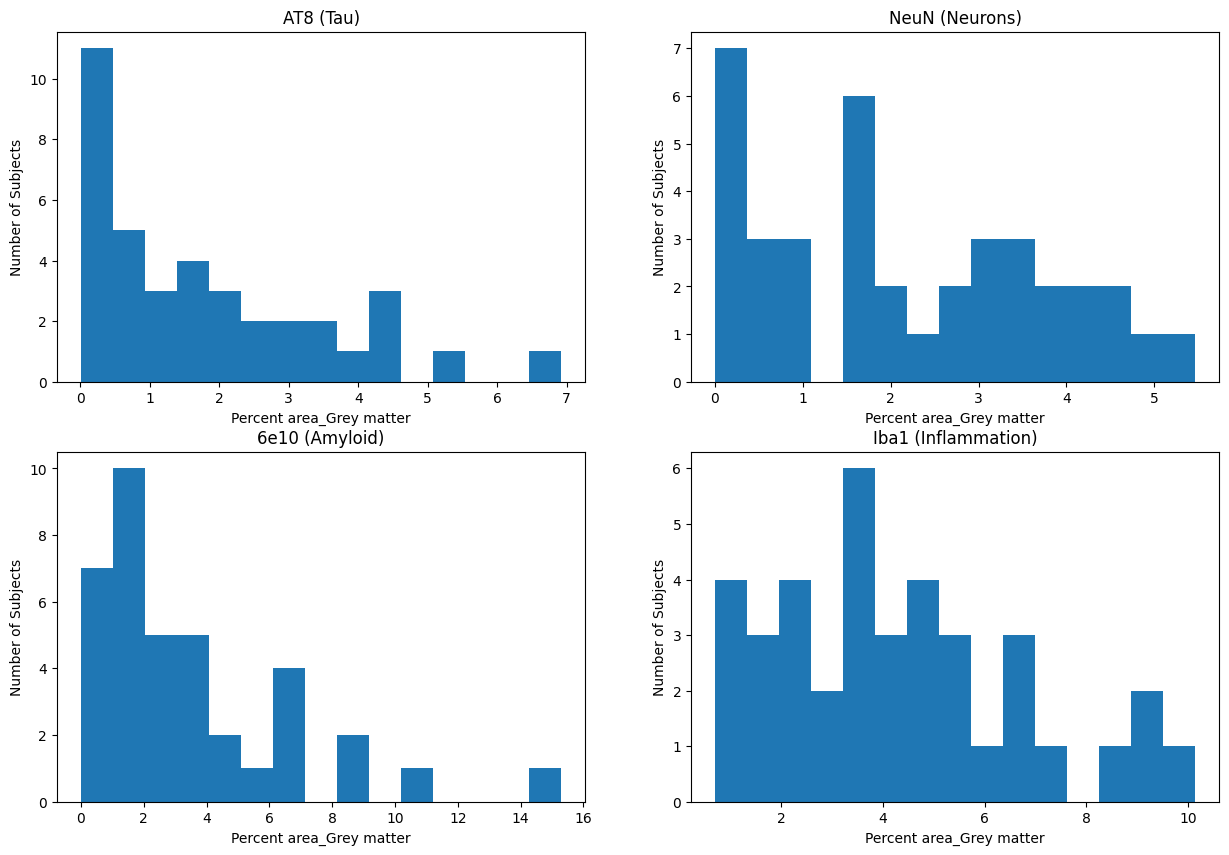

In [7]:
#making histograms
fig, ax = plt.subplots(2,2, figsize = (15, 10))

ax[0,0].hist(clean_data['percent AT8 positive area_Grey matter'], bins = 15)
ax[0,0].set_title('AT8 (Tau)')
ax[0,0].set_xlabel('Percent area_Grey matter')
ax[0,0].set_ylabel('Number of Subjects')

ax[0,1].hist(clean_data['percent NeuN positive area_Grey matter'], bins = 15)
ax[0,1].set_title('NeuN (Neurons)')
ax[0,1].set_xlabel('Percent area_Grey matter')
ax[0,1].set_ylabel('Number of Subjects')

ax[1,0].hist(clean_data['percent 6e10 positive area_Grey matter'], bins = 15)
ax[1,0].set_title('6e10 (Amyloid)')
ax[1,0].set_xlabel('Percent area_Grey matter')
ax[1,0].set_ylabel('Number of Subjects')

ax[1,1].hist(clean_data['percent Iba1 positive area_Grey matter'], bins = 15)
ax[1,1].set_title('Iba1 (Inflammation)')
ax[1,1].set_xlabel('Percent area_Grey matter')
ax[1,1].set_ylabel('Number of Subjects')

#do these graphs make sense

In [8]:
#Skewness Tests of data
print(stats.skewtest(clean_data['percent AT8 positive area_Grey matter']))
print(stats.skewtest(clean_data['percent NeuN positive area_Grey matter']))
print(stats.skewtest(clean_data['percent 6e10 positive area_Grey matter']))
print(stats.skewtest(clean_data['percent Iba1 positive area_Grey matter']))

SkewtestResult(statistic=np.float64(2.6927483480422922), pvalue=np.float64(0.00708657355067648))
SkewtestResult(statistic=np.float64(0.7710386386566508), pvalue=np.float64(0.44068402954190133))
SkewtestResult(statistic=np.float64(3.7393302060258833), pvalue=np.float64(0.00018451122679689495))
SkewtestResult(statistic=np.float64(1.777904721128478), pvalue=np.float64(0.0754195047082079))


In [9]:
#38 subjects
#AT8 skew 2.69, pva;ue 0.007
#NeuN skew 0.77, pvalue 0.44
#6e10 skew 3.74, pvalue 0.0002
#Iba1 skew 1.78, pvalue 0.075

*Figure 1.* Distribution of pathological markers across subjects (n = 38).
Histograms show the distribution of percent area in grey matter for AT8 (tau), NeuN (neurons), 6e10 (amyloid), and Iba1 (inflammation).

Skewness tests indicated that AT8 (stat = __, p = __), NeuN (stat = __, p = __), 6e10 (stat = __, p = __), and Iba1 (stat = __, p = __) were [normally distributed / significantly skewed].

AT8 - most donors show low tau burden, with most of the subjects near 0. fewer donors show high tau accumulation

NeuN - same thing but more distribution in neuron positive area

6e10 - most donors show low amyloid plaque but there is a spike in the middle, likely suggesting disease pathology

Iba1 - way more distribution among subjects

In [14]:
#set up bar graphs
clean_data['Years of education'].median() #16.0
clean_data['Age of onset cognitive symptoms'].median() #84.0

clean_data['education_group'] = clean_data['Years of education'].apply(
    lambda x: 'High' if x > 16 else 'Low'
)

clean_data['onset_group'] = clean_data['Age of onset cognitive symptoms'].apply(
    lambda x: 'Early' if x < 84 else "Late"
)

edu_groups = clean_data.groupby('education_group').size()
age_groups = clean_data.groupby('onset_group').size()

/tmp/ipykernel_9146/1706438224.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['education_group'] = clean_data['Years of education'].apply(
/tmp/ipykernel_9146/1706438224.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_data['onset_group'] = clean_data['Age of onset cognitive symptoms'].apply(


Text(0.5, 1.0, 'Onset Distribution')

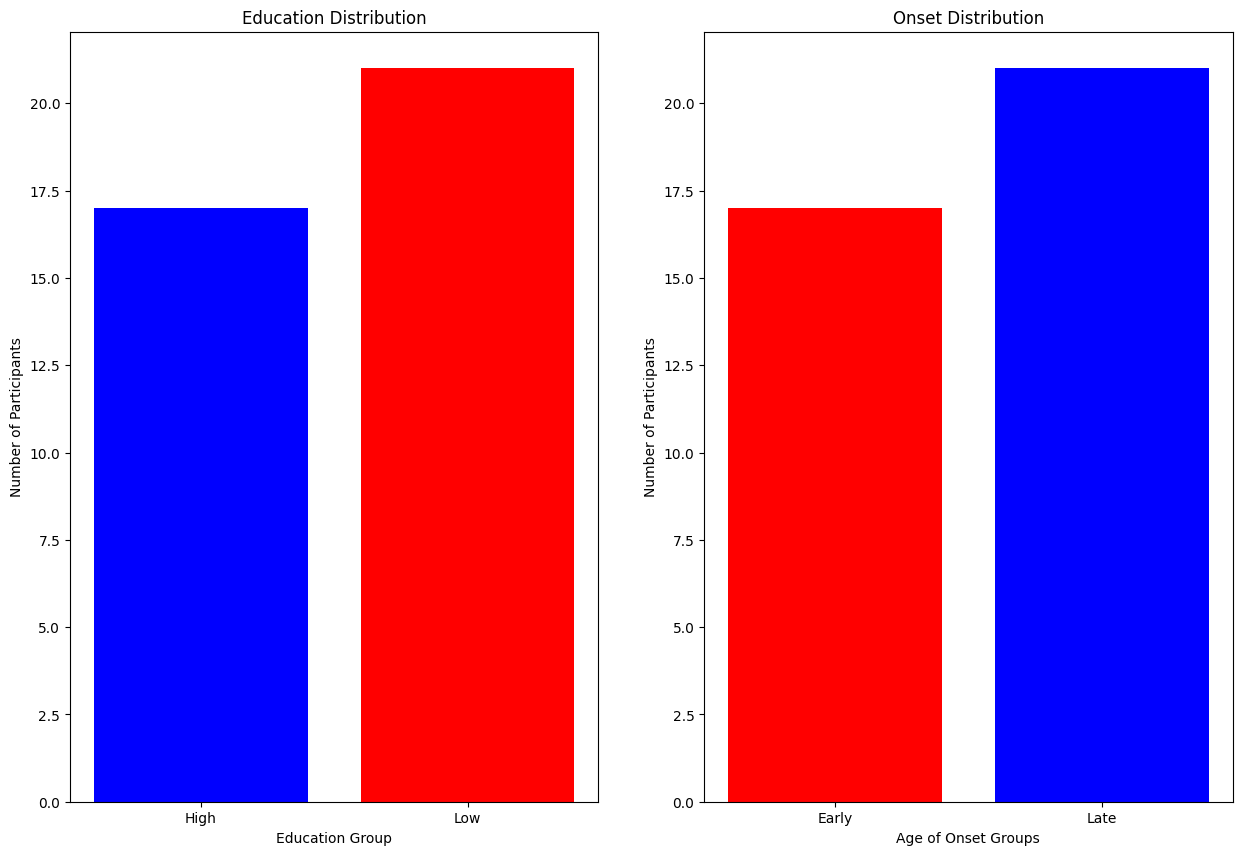

In [15]:
#bar graphs
fig, ax = plt.subplots(1,2, figsize = (15, 10))

for group in edu_groups.index:
  if group == 'High':
    color = 'blue'
  else:
    color = 'red'

  ax[0].bar(group, edu_groups[group], color=color)

ax[0].set_xlabel ('Education Group')
ax[0].set_ylabel ('Number of Participants')
ax[0].set_title('Education Distribution')

for group in age_groups.index:
  if group == "Early":
    color = 'red'
  else:
    color = 'blue'

  ax[1].bar(group, age_groups[group], color=color)

ax[1].set_xlabel ('Age of Onset Groups')
ax[1].set_ylabel ('Number of Participants')
ax[1].set_title('Onset Distribution')


In [16]:
#value_counts
print(clean_data['education_group'].value_counts())
print(clean_data['onset_group'].value_counts())

education_group
Low     21
High    17
Name: count, dtype: int64
onset_group
Late     21
Early    17
Name: count, dtype: int64


*Figure 2.* Figure 2. Distribution of participants across groups.
Bar graphs show the number of subjects in each education and age of onset group.

The education groups consisted of Low education (n = __) and High education (n = __).

The age of onset groups consisted of Early onset (n = __) and Late onset (n = __).

more participants had lower education. more particpants had a later onset of cognitive symptoms.

Text(0.5, 1.0, 'Amyloid vs. Inflammation in Onset')

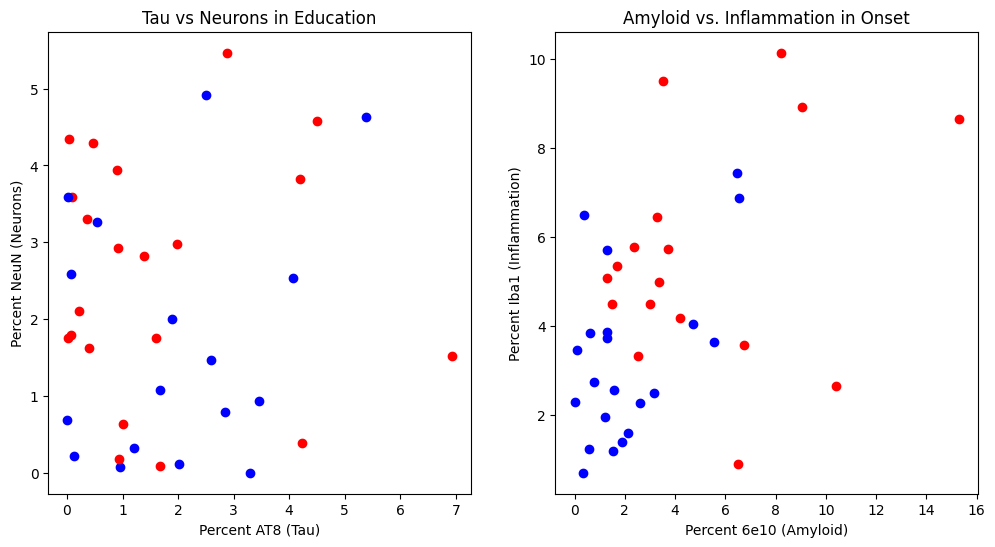

In [19]:
#scatter plots
fix, ax = plt.subplots(1,2, figsize = (12,6))

for i in range(len(clean_data)):
  if clean_data['education_group'].iloc[i] == 'High':
    color = 'blue'
  else:
    color = 'red'

  ax[0].scatter(clean_data['percent AT8 positive area_Grey matter'].iloc[i], clean_data['percent NeuN positive area_Grey matter'].iloc[i], color=color)
ax[0].set_xlabel('Percent AT8 (Tau)')
ax[0].set_ylabel('Percent NeuN (Neurons)')
ax[0].set_title('Tau vs Neurons in Education')

for i in range(len(clean_data)):
  if clean_data['onset_group'].iloc[i] == 'Early':
    color = 'red'
  else:
    color = 'blue'

  ax[1].scatter(clean_data['percent 6e10 positive area_Grey matter'].iloc[i], clean_data['percent Iba1 positive area_Grey matter'].iloc[i], color=color)
ax[1].set_xlabel('Percent 6e10 (Amyloid)')
ax[1].set_ylabel('Percent Iba1 (Inflammation)')
ax[1].set_title('Amyloid vs. Inflammation in Onset')

Education - blue = high, red = low. There seems to be no strong visible protective effect of education. Slight negative relationship between tau pathology and neuronal density which was predicted. But no clear separation between education groups.

Onset - blue = late, red = early. It seems to have a positive trend, where as amyloid increases, so does inflammation. Late onset is more clustered at lower values --> early onset may be associated with more extreme pathology

In [18]:
#finding correlation between scatterplots
r_at8_neun = pearsonr(clean_data['percent AT8 positive area_Grey matter'], clean_data['percent NeuN positive area_Grey matter'])
r_amyloid_iba1 = pearsonr(clean_data['percent 6e10 positive area_Grey matter'], clean_data['percent Iba1 positive area_Grey matter'])

print(r_at8_neun) #0.06, pvalue 0.68
print(r_amyloid_iba1) #0.48, pvalue 0.002

PearsonRResult(statistic=np.float64(0.0676216222427319), pvalue=np.float64(0.6866649286851378))
PearsonRResult(statistic=np.float64(0.48426730574080973), pvalue=np.float64(0.002064681781333541))


In [22]:
#prep for boxplots and correlations
#making groups
high_edu = clean_data[clean_data['education_group'] == 'High']
low_edu = clean_data[clean_data['education_group'] == 'Low']
early_onset = clean_data[clean_data['onset_group'] == 'Early']
late_onset = clean_data[clean_data['onset_group'] == 'Late']

#extracting data
high_at8 = high_edu['percent AT8 positive area_Grey matter']
low_at8 = low_edu['percent AT8 positive area_Grey matter']

high_neun = high_edu['percent NeuN positive area_Grey matter']
low_neun = low_edu['percent NeuN positive area_Grey matter']

early_6e10 = early_onset['percent 6e10 positive area_Grey matter']
late_6e10 = late_onset['percent 6e10 positive area_Grey matter']

early_iba1 = early_onset['percent Iba1 positive area_Grey matter']
late_iba1 = late_onset['percent Iba1 positive area_Grey matter']

In [23]:
#correlations between scatter groups
print(pearsonr(high_at8, high_neun))
print(pearsonr(low_at8, low_neun))
print(pearsonr(early_6e10, early_iba1))
print(pearsonr(late_6e10, late_iba1))

PearsonRResult(statistic=np.float64(0.22137467895056523), pvalue=np.float64(0.39316289297946694))
PearsonRResult(statistic=np.float64(0.0008161328401206508), pvalue=np.float64(0.9971986645029232))
PearsonRResult(statistic=np.float64(0.2717187915458609), pvalue=np.float64(0.29142324110873996))
PearsonRResult(statistic=np.float64(0.5092659466555675), pvalue=np.float64(0.01837524274541216))


*Figure 3.* Relationships between pathological markers across and within groups.
Scatter plots show the relationship between AT8 (tau) and NeuN (neuronal marker), and between 6e10 (amyloid) and Iba1 (inflammation) across all subjects (n = 38).

Across all subjects, AT8 and NeuN showed a [weak/moderate/strong, positive/negative] correlation (r = __, p = __). Amyloid and inflammation showed a [weak/moderate/strong, positive/negative] correlation (r = __, p = __).

When separated by education group, the relationship between AT8 and NeuN differed between High and Low education groups, with correlations of r = __ and r = __ respectively, suggesting [stronger/weaker/similar] association in the High education group.

When separated by age of onset, the Early onset group showed a correlation of r = __. The Late onset group could not be reliably estimated due to insufficient sample size after filtering for missing data.

Text(0.5, 1.0, 'Inflammation and Onset of Symptoms')

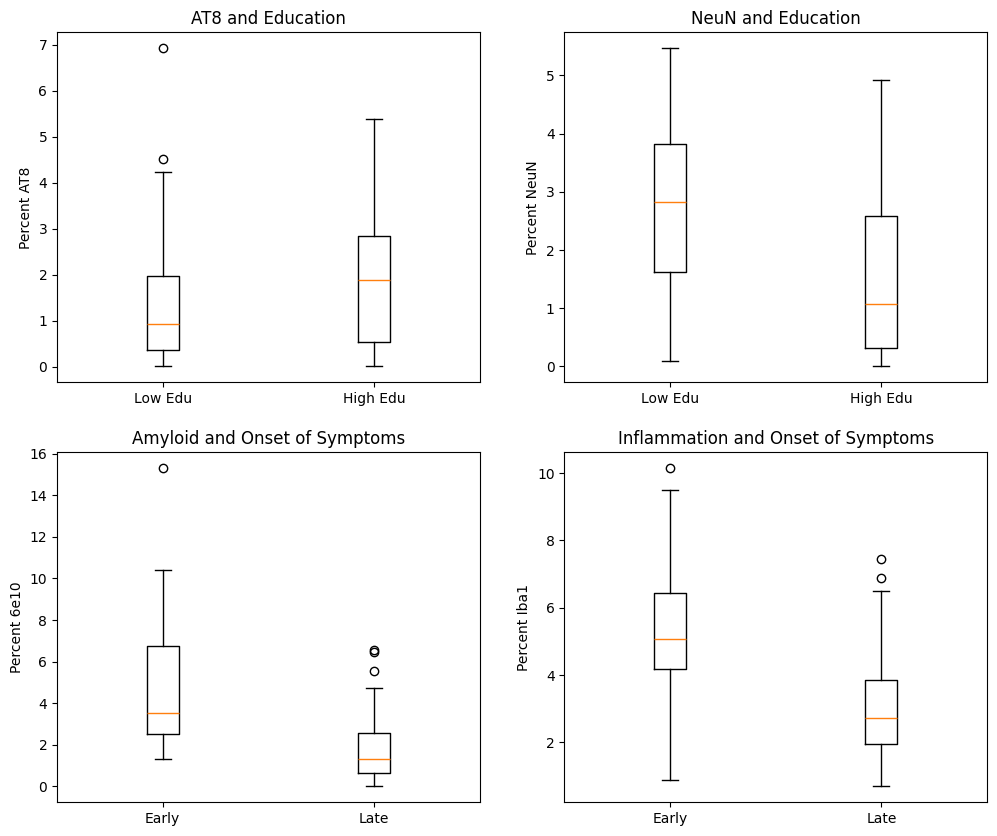

In [24]:
#boxplots
fig, ax = plt.subplots(2,2, figsize = (12,10))
at8_data = [low_at8.tolist(), high_at8.tolist()]

ax[0,0].boxplot(at8_data)
ax[0,0].set_xticks([1,2])
ax[0,0].set_xticklabels(['Low Edu', 'High Edu'])
ax[0,0].set_ylabel('Percent AT8')
ax[0,0].set_title('AT8 and Education')

neun_data = [low_neun.tolist(), high_neun.tolist()]

ax[0,1].boxplot(neun_data)
ax[0,1].set_xticks([1,2])
ax[0,1].set_xticklabels(['Low Edu', 'High Edu'])
ax[0,1].set_ylabel('Percent NeuN')
ax[0,1].set_title('NeuN and Education')

amyloid_data = [early_6e10.tolist(), late_6e10.tolist()]

ax[1,0].boxplot(amyloid_data)
ax[1,0].set_xticks([1,2])
ax[1,0].set_xticklabels(['Early', 'Late'])
ax[1,0].set_ylabel('Percent 6e10')
ax[1,0].set_title('Amyloid and Onset of Symptoms')

iba1_data = [early_iba1.tolist(), late_iba1.tolist()]

ax[1,1].boxplot(iba1_data)
ax[1,1].set_xticks([1,2])
ax[1,1].set_xticklabels(['Early', 'Late'])
ax[1,1].set_ylabel('Percent Iba1')
ax[1,1].set_title('Inflammation and Onset of Symptoms')

In [26]:
#boxplot comparisons
#AT8 vs Education (not normal)
print(stats.mannwhitneyu(high_at8, low_at8))
#NeuN vs Education (normal)
print(stats.ttest_ind(high_neun, low_neun))
#6e10 vs Onset (not normal)
print(stats.mannwhitneyu(early_6e10, late_6e10))
#Iba1 vs Onset (normal)
print(stats.ttest_ind(early_iba1, late_iba1))

MannwhitneyuResult(statistic=np.float64(202.0), pvalue=np.float64(0.4995293352868847))
TtestResult(statistic=np.float64(-1.6443722106194054), pvalue=np.float64(0.10880526307595725), df=np.float64(36.0))
MannwhitneyuResult(statistic=np.float64(290.0), pvalue=np.float64(0.0011191563825857483))
TtestResult(statistic=np.float64(3.081310922722808), pvalue=np.float64(0.003936969424807514), df=np.float64(36.0))


Figure 4. Group differences in pathological markers. Box plots show differences in percent area of AT8 (tau), NeuN (neurons), 6e10 (amyloid), and Iba1 (inflammation) between groups.

AT8 levels did not significantly differ between High and Low education groups (U = 202.0, p = 0.500), indicating no group effect on tau pathology.

NeuN levels also did not significantly differ between education groups (t = -1.64, p = 0.109), suggesting no significant difference in neuronal marker expression.

For age of onset, 6e10 levels significantly differed between Early and Late onset groups (U = 290.0, p = 0.001), indicating higher amyloid burden on the Early onset group.

Iba1 levels also significantly differed between onset groups (t = 3.08, p = 0.004), suggesting differences in inflammation between Early and Late onset individuals. Early onset showing increased inflammation.

Tau in Education - **instead of high education having less tau, it looks like they have similar or even high levels of tau.**
NeuN in Education - low education has a higher median NeuN. high education group is lower and more spread out. **High education is not associated with more neurons here.**

*Education takeaway* - **my data does NOT show a clear protective effect of education.** this could be because of sample size, variability, or completixty of "cognitive reserve".

Amyloid vs Onset - early onset has a much higher median, late onset is clustered low. There is a larger spread of data and ~15 extreme outliers. Very clear effect: **Earlier onset is associated with higher amyloid burden.**

Inflammation vs. Onset - early onset has high median inflammation, more variability, late onset is lower overall. **Early onset is associated with increased neuroinflammation.**

*Onset takeaway* - my data shows that the age of onset has a strong relationship with pathology. Early onset = more severe disease markers. **Consistent with hypothesis**



Despite variability and overlap between groups, education did not show a clear protective relationship with tau pathology or neuronal preservation. Age of onset demonstrated a strong association with disease severity. Early onset individuals exhibited higher amyloid burden and increased neuroinflammation, suggesting a more aggressive pathological profile.

*Instructions for POSTER*

**Figure Legends**

description of graph
a. results of skewness tests
b. description of how many observations of each group are in your data set
c. a description of the correlation between your variables, and how that correlation might differ by group
d. results from t-test if data is normally distributed (statistic and p-value), or Wilcoxons rank sum test if data is not normally distributed.

**Background**

What are my variables, why I am interested in comparing them, what they are, the relationship they have with Alzheimers disease

Why did you pick these variables, or these specific comparisons.

What do you already know about how your dependent variables differ? what has already been found about the relationship with these variables? why is comparing them important?
- need at least 3 references (scientific, peer-reviewed articles)
- (Last name, first name, title, volume: page numbers, year of publication)

This section also contains - hypothesis for each analysis.

**Methods**

This section contains all the code, copied and pasted exactly as I ran it.

**Conclusions**

Interpretation of the results - did your analyses support original hypothesis? What new information was gained from doing these analyses?

**Future Directions**

Paragraph with a couple ideas about important experiments that should be done to further elucidate the relationship between the groups that you chose.

###**I still need to add skew test, t tests, and correlation to my data** - then poster